# Détection des anomalies - les données
## Charger les configurations et les fonctions

In [1]:
%run helpers.py

## Créer notre ensemble de données

In [ ]:
dataset = create_dataset()

# Choisissez le nombre d'échantillons d'entraînement à utiliser :
# Portion des échantillons d'entraînement qui sera des malwares (logiciels malveillants) :

<div class="alert alert-info">
<h3>Important</h3>


La détection d'anomalies est une approche d'**apprentissage automatique non supervisée**.
Ainsi, le modèle **ne verra jamais les étiquettes de classe**, et ne pourra donc pas les comparer à ses propres "décisions" pour obtenir du feedback.    
    
Cependant, nous utiliserons ici les étiquettes de classe pour:   
- analyser et visualiser les données,   
- puis pour évaluer notre modèle plus en détail.
</div>

## On va explorer les données d'entraînement et visualiser 1000 échantillons

1) Nous examinons la distribution des différents types d'attaques dans nos données d'entraînement.

2) Nous utilisons TSNE (t-distributed stochastic neighbor embedding / encastrement stochastique de voisins) pour explorer une partie de nos données d'entraînement.   
Le TSNE-plot réduit nos 51 caractéristiques à 2 dimensions en essayant de représenter fidèlement les structures locales.

Your training set has the following composition:


,frequency
class,
normal,9000
neptune,246
ipsweep,169
satan,165
smurf,118
portsweep,114
nmap,59
warezclient,54
back,36


Plotting 1000 samples of the training data


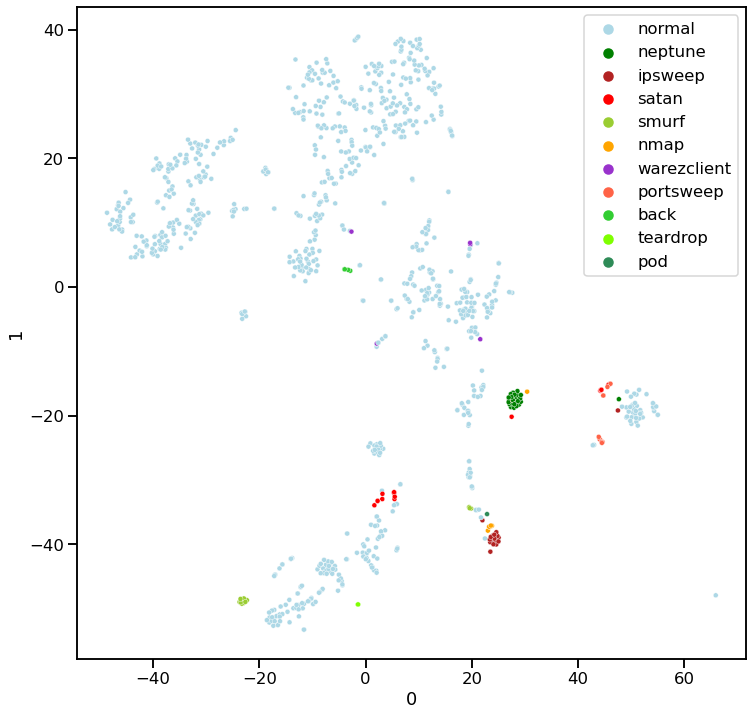

In [3]:
explore_and_visualise_training_data(dataset)

<div class="alert alert-success">
<h2>Questions - Partie 1</h2>
    
L'objectif des questions suivantes est de  
- d'estimer la performance de notre modèle et   
- d'anticiper les problèmes que le modèle pourrait rencontrer.
    
Remarque : ces questions n'ont de sens que pour les données d'entraînement qui ont été contaminées avec **malwares (_logiciels malveillants_)**
    
Qu'observez-vous à propos de

<ol>
<li> la <b>fréquence des différents types de malwares</b> dans notre ensemble de données ?
<li> la <b>distribution des types de malwares</b> dans le graphe TSNE ?
<li> la <b>distribution des échantillons normaux</b> dans le graphe TSNE ?
<li>Quels <b>types de malwares</b> devraient être <b>faciles à trouver</b>, et lesquels seraient <b>plus difficiles à détecter</b> ?
</ol>
</div>

Mes observations (pour le cas 10000 échantillons avec 10% de malware) :

<ol>
<li> Les différentes classes de malwares ne sont pas distribuées de manière égale. Pod et guess_psswrd sont très rares alors que neptune, ipsweep et satan sont assez courants.</li>
<li> SCertains types de malwares forment leurs propres clusters disjoints (ici neptune, smurf et ipsweep). <br>
    Certains échantillons sont très proches des échantillons normaux (ici satan, warezclient).
</li>
<li> Les échantillons normaux forment plusieurs clusters, mais il y en a aussi plusieurs qui sont assez isolés dans le graphe. Ceux-ci peuvent conduire à de fausses alertes. </li>
<li> Les logiciels malveillants qui sont proches de nombreux échantillons normaux seront plus difficiles à trouver. Les logiciels malveillants communs formant des grappes pourraient être interprétés à tort comme suffisamment communs et donc comme normaux.</li>
</ol>

# Détection d'anomalies - le modèle
## Entraînement de notre modèle

La **contamination attendue (expected_contamination)** est la proportion d'anomalies (attaques) que nous attendons dans l'ensemble de test réel.  
**Attention**, cette valeur est indépendante de la *portion d'attaques* que nous avons choisi de placer dans les données d'entraînement.


**L'ACP (Analyse en Composantes Principales)** transforme nos données en essayant d'identifier les directions (= combinaisons de caractéristiques) dans les données dans lesquelles nos données varient le plus. Cela peut aider l'algorithme de la forêt d'isolation à isoler les anomalies plus rapidement, ou pas. On va voir.

In [4]:
model, dataset = build_anomaly_detector(
    dataset,
    expected_contamination=0.1,      # value between 0 and 0.5
    with_PCA = False)                # True / False

## Évaluer la performance

1) Nous examinons les scores attribués par la **fonction de décision** à nos différents échantillons. Les échantillons ayant des scores négatifs sont marqués comme des anomalies.

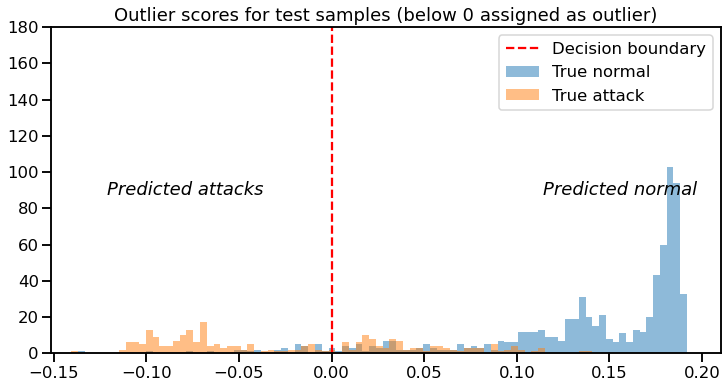

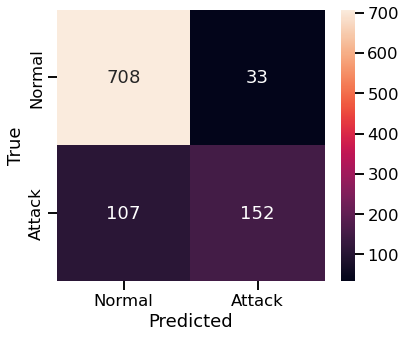

Summary report:
Attacks identified correctly (true positive): 152  of  259 ( 58.7 %)
Attacks missed (false negative): 107  of  259 ( 41.3 %)
False alarms (false positive): 33  of 741 ( 4.5 %)
Total number of misclassified samples: 140


In [5]:
evaluate_model(dataset, model)

<div class="alert alert-success">
<h2>Questions - Partie 2</h2>

<p>Jetons un coup d'œil aux les résultats ci-dessus. Regardez d'abord tout, puis essayez de répondre aux questions suivantes :</p>

<ol>
<li>  Dans le premier graphique, combien d'échantillons bleus se trouvent sur le côté gauche ?</li>
<li>  Dans le premier graphique, combien d'échantillons orange se trouvent sur le côté droit ?</li>
<li>  Laquelle de ces deux prédictions erronées est la pire pour nous ?</li>
</ol>

</div>

Mes observations (pour le cas 10000 échantillons avec 10% de malware) :

1.  Nous recherchons des échantillons normaux étiquetés comme malware, c'est-à-dire des fausses attaques (carré en haut à droite). Il y en a donc 33.
2.  Nous recherchons des logiciels malveillants étiquetés comme des échantillons normaux, c'est-à-dire des attaques manquées (carré en bas à gauche). Il y en a donc 107.
3. Les prédictions erronées les plus coûteuses sont les fausses attaques (quel que soit leur nombre exact).



## Regardons de plus près nos performances.

1) Nous examinons la performance de nos prédictions au niveau des types d'attaque individuels.

2) Nous localisons les échantillons mal classés dans notre ensemble de test. (**Les échantillons mal classés sont mis en évidence par des triangles, et leur couleur donne l'étiquette vraie**)

In [ ]:
detailed_evaluation(dataset, model)

<div class="alert alert-success">
<h2>Questions - Partie 3</h2>

Comparons nos attentes établies dans la première partie avec les performances réelles.
    
<ol>
<li>  Pour quels types de logiciels malveillants notre modèle a-t-il donné de bons résultats, et pour lesquels a-t-il donné de mauvais résultats ?</li>
<li>  Cela correspond-il aux observations et aux attentes de la première partie ?</li>
</ol>   
<p>Les triangles bleu foncé indiquent les fausses alertes, c'est-à-dire un comportement normal qui a été prédit comme étant un logiciel malveillant. <br>
Les autres triangles indiquent des logiciels malveillants qui n'ont pas été détectés.</p>

<ol start="3">
<li>  Qu'observez-vous concernant l'emplacement des fausses alarmes ?</li>
<li>  Qu'observez-vous à propos de l'emplacement des logiciels malveillants non détectés ?</li>
<li>  Vos observations correspondent-elles aux observations et aux attentes formulées dans la première partie ?</li>
</ol>

</div>

Mes observations:

<ol>
<li>  Notre modèle fonctionne très bien sur Neptune et portsweep, comme prévu il a eu du mal avec les classes plus rares. De manière surprenante, il a également eu beaucoup de mal avec ipsweep.</li>
<li>  Pour être juste, seulement en partie.</li>
<li>  Certaines fausses alarmes sont assez isolées, ce qui aurait pu déclencher l'alerte. D'autres sont proches d'autres malwares.
<li>  Certains échantillons manqués de warezclient et satan se cachent parmi les échantillons normaux. Mais d'autres attaques manquées forment de grands groupes.</li>
<li>  Il semble que certaines régions de malveillance plus denses dans les données d'apprentissage aient été considérées comme normales par le modèle.</li>
</ol> 

# Explorations supplémentaires

Sauf indication contraire, toutes les observations ci-dessous sont basées sur 10000 échantillons et 10% de malware dans les données d'entraînement.

## Exploration 1


<div class="alert alert-success">

Faisons varier le paramètre `expected_contamination` qui est utilisé par le modèle pour prendre des décisions. <br> 
Il suffit d'exécuter les cellules de la section 2 "Détection d'anomalies - le modèle".

Qu'observez-vous concernant la distribution des scores aberrants et la position de la limite de décision ? <br>
    
</div>

Mes observations:

En fixant la valeur de `expected_contamination` à 0,2, la décision se déplace davantage vers la droite, ce qui entraîne plus de fausses alarmes mais beaucoup moins d'attaques manquées. En particulier, nmap, smurf et ipsweep s'en sortent mieux.

## Exploration 2


<div class="alert alert-success">

Vous devez réexécuter le cahier entier ici.

1. Variez la taille de vos données d'entraînement.<br>
2. Variez la proportion d'attaques dans vos données d'entraînement.<br>
3. En particulier, voyons comment le modèle se comporte lorsque nous **utilisons uniquement des données d'entraînement totalement propres, sans aucune anomalie**.<br>
</div>

Mes observations:

L'entraînement sur 10000 mais avec 0% de malware donne de meilleurs résultats (43 attaques manquées). Neptune, ipsweep et portsweep ont été parfaitement détectés. Smurf et nmap sont également très bons.

## Exploration 3


<div class="alert alert-success">
    
Voyons si l'utilisation de l'ACP (Analyse des composantes principales) avant l'entraînement de notre modèle est utile. <br>
Vous avez seulement besoin d'exécuter les cellules de la section 2 "Détection d'anomalies - le modèle".     <br>
Définissez `with_PCA = True` dans la commande `build_anomaly_detector`. <br>
</div>

Dans ce cas précis, cela a encore aggravé les choses (150 attaques manquées). En particulier, Neptune a échoué.

Sur 10000 échantillons propres, il a amélioré la situation (31 attaques manquées).